# Intent Parsing & Classification con LLMs Locales

Este notebook implementa un clasificador de intenciones usando **`instructor`** — la librería estándar para extracción estructurada desde LLMs.

**Mejoras sobre la implementación base:**
- `instructor` reemplaza el parseo manual de JSON → más limpio y robusto
- Reintentos automáticos si el LLM devuelve un formato incorrecto
- Validación de datos integrada vía Pydantic v2
- Soporte para múltiples backends: Ollama, OpenAI, Anthropic

**Stack:**
```
instructor  →  maneja el ciclo prompt ↔ validación Pydantic
pydantic    →  define y valida la estructura de salida
openai      →  cliente HTTP (compatible con Ollama/LM Studio)
```

## 1. Instalación

In [7]:
#%pip install -q instructor openai pydantic

## 2. Imports

In [8]:
from __future__ import annotations

from typing import Optional

import instructor
from openai import OpenAI
from pydantic import BaseModel, Field, field_validator

## 3. Esquema de salida (Pydantic)

`intent` es un `str` libre: el LLM deduce y nombra la intención por sí solo, sin estar limitado a una lista predefinida. La descripción del campo guía el formato esperado (PascalCase, verbo + sustantivo) sin restringirlo.

El `field_validator` en `confidence` garantiza que el LLM no devuelva valores fuera de rango — si lo hace, Pydantic lanza un error que `instructor` usa para pedir una corrección automáticamente.

In [9]:
class ParsedIntent(BaseModel):
    """Resultado estructurado del análisis de una consulta de usuario."""

    intent: str = Field(
        description=(
            "Intención principal detectada. Usa PascalCase y sé específico, "
            "ej. 'SearchProduct', 'RequestQuote', 'TrackOrder'. "
            "Si no encaja en ninguna categoría conocida, inventa un nombre descriptivo."
        )
    )
    product_name: Optional[str] = Field(
        default=None,
        description="Nombre del producto mencionado, si existe. None si no aplica."
    )
    quantity: Optional[int] = Field(
        default=None,
        description="Cantidad solicitada, si se menciona explícitamente."
    )
    confidence: float = Field(
        description="Nivel de confianza en la clasificación, entre 0.0 y 1.0."
    )
    reasoning: str = Field(
        description="Breve explicación de por qué se eligió esa intención."
    )

    @field_validator("confidence")
    @classmethod
    def confidence_in_range(cls, v: float) -> float:
        if not 0.0 <= v <= 1.0:
            raise ValueError(f"confidence debe estar entre 0 y 1, recibido: {v}")
        return round(v, 2)

## 4. Configuración del cliente

`instructor.from_openai()` envuelve el cliente con la lógica de:
1. Inyectar el schema JSON de Pydantic en el prompt
2. Parsear la respuesta
3. Reintentar automáticamente si la validación falla (por defecto hasta 3 intentos)

El cliente de OpenAI apunta a Ollama localmente — solo cambia `base_url` para usar otro backend.

In [10]:
# --- Ollama (local) ---
raw_client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="qwen3",  # Ollama no requiere API key, pero el cliente la pide
)

# --- OpenAI (cloud) — descomenta y cambia la base_url si lo prefieres ---
# raw_client = OpenAI(api_key="sk-...")

# instructor envuelve el cliente añadiendo validación estructurada
client = instructor.from_openai(raw_client, mode=instructor.Mode.JSON)

MODEL = "qwen3:8b"  # Cambia al modelo que tengas disponible en Ollama

## 5. Clasificador de intenciones

La clase es mínima — `instructor` se encarga de todo el ciclo de parseo/validación/reintento.
El sistema prompt le da contexto de dominio al modelo.

In [11]:
SYSTEM_PROMPT = """
Eres un clasificador de intenciones para un sistema de procurement basado en el protocolo Beckn.
Analiza la consulta del usuario y devuelve la intención más precisa.

Contexto del dominio:
- Los usuarios buscan productos industriales, equipos y materiales
- Pueden solicitar cotizaciones (RFQ), hacer pedidos o hacer seguimiento a compras
- Los proveedores están en una red Beckn descentralizada
""".strip()


class IntentClassifier:
    def __init__(self, model: str = MODEL, max_retries: int = 3):
        self.model = model
        self.max_retries = max_retries

    def classify(self, query: str) -> ParsedIntent:
        """Clasifica la intención de una consulta de usuario."""
        return client.chat.completions.create(
            model=self.model,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": query},
            ],
            response_model=ParsedIntent,   # instructor usa esto para parsear y validar
            max_retries=self.max_retries,
        )

## 6. Pruebas con ejemplos

In [12]:
classifier = IntentClassifier()

test_queries = [
    "Necesito 500 unidades de válvulas de acero inoxidable de 2 pulgadas",
    "¿Cuánto cuesta el compresor de aire modelo AC-200?",
    "Quiero cancelar la orden PO-2024-0892",
    "¿En qué estado está mi pedido de tornillos M8?",
    "¿Tienen stock de filtros HEPA H14?",
    "Necesito una cotización para 10 laptops Dell Latitude",
    "Buen día",
]

for query in test_queries:
    result = classifier.classify(query)
    print(f"Query     : {query}")
    print(f"Intent    : {result.intent}")
    print(f"Producto  : {result.product_name or '—'}")
    print(f"Cantidad  : {result.quantity or '—'}")
    print(f"Confianza : {result.confidence:.0%}")
    print(f"Razón     : {result.reasoning}")
    print("-" * 60)

Query     : Necesito 500 unidades de válvulas de acero inoxidable de 2 pulgadas
Intent    : RequestQuote
Producto  : válvulas de acero inoxidable de 2 pulgadas
Cantidad  : 500
Confianza : 95%
Razón     : El usuario especifica una cantidad clara (500 unidades) y describe el producto detallado (válvulas de acero inoxidable de 2 pulgadas), lo que indica una solicitud formal de cotización (RFQ) para adquirir el producto.
------------------------------------------------------------
Query     : ¿Cuánto cuesta el compresor de aire modelo AC-200?
Intent    : RequestQuote
Producto  : compresor de aire modelo AC-200
Cantidad  : —
Confianza : 95%
Razón     : La consulta específica sobre el precio de un producto industrial (compresor de aire modelo AC-200) corresponde a una solicitud de cotización (RFQ), ya que el usuario busca información sobre costos antes de tomar una decisión de compra.
------------------------------------------------------------
Query     : Quiero cancelar la orden PO-2024-08

## 7. Procesamiento por lotes

Para volumen alto de consultas: procesa en paralelo con `ThreadPoolExecutor`.
El resultado es un DataFrame de pandas para análisis inmediato.

In [13]:
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd


def classify_batch(queries: list[str], max_workers: int = 4) -> pd.DataFrame:
    """Clasifica múltiples consultas en paralelo y devuelve un DataFrame."""
    results = {}

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(classifier.classify, q): q for q in queries}

        for future in as_completed(futures):
            query = futures[future]
            try:
                r = future.result()
                results[query] = {
                    "intent":       r.intent,
                    "product_name": r.product_name,
                    "quantity":     r.quantity,
                    "confidence":   r.confidence,
                    "reasoning":    r.reasoning,
                    "error":        None,
                }
            except Exception as e:
                results[query] = {"intent": None, "error": str(e)}

    df = pd.DataFrame.from_dict(results, orient="index")
    df.index.name = "query"
    return df


df = classify_batch(test_queries)
df

,intent,product_name,quantity,confidence,reasoning,error
query,,,,,,
¿En qué estado está mi pedido de tornillos M8?,TrackOrder,tornillos M8,NaN,0.95,La consulta explicita la necesidad de seguimie...,None
¿Cuánto cuesta el compresor de aire modelo AC-200?,RequestQuote,compresor de aire modelo AC-200,NaN,0.95,La consulta específica sobre el costo de un pr...,None
Necesito 500 unidades de válvulas de acero inoxidable de 2 pulgadas,RequestQuote,válvulas de acero inoxidable de 2 pulgadas,500.0,0.95,El usuario solicita una cantidad específica de...,None
Quiero cancelar la orden PO-2024-0892,CancelOrder,NaN,NaN,0.85,El usuario solicita cancelar una orden específ...,None
¿Tienen stock de filtros HEPA H14?,SearchProduct,filtros HEPA H14,NaN,0.95,La consulta se enfoca en verificar la disponib...,None
Necesito una cotización para 10 laptops Dell Latitude,RequestQuote,laptops Dell Latitude,10.0,0.95,El usuario solicita explícitamente una cotizac...,None
Buen día,GeneralInquiry,NaN,NaN,0.30,El mensaje 'Buen día' es una saluda general qu...,None


## 8. Distribución de intenciones detectadas

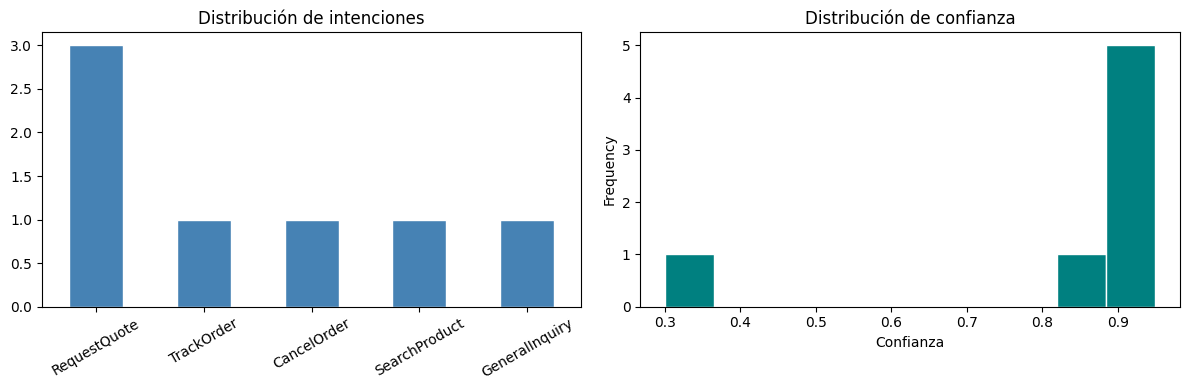

In [14]:
import matplotlib.pyplot as plt

counts = df["intent"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras de intenciones
counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Distribución de intenciones")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# Distribución de confianza
df["confidence"].dropna().plot(kind="hist", ax=axes[1], bins=10, color="teal", edgecolor="white")
axes[1].set_title("Distribución de confianza")
axes[1].set_xlabel("Confianza")

plt.tight_layout()
plt.show()

## 9. Usar Anthropic Claude en lugar de Ollama

`instructor` soporta el SDK de Anthropic de forma nativa — misma clase `ParsedIntent`, mismo clasificador, solo cambia el cliente.

In [15]:
# %pip install -q anthropic

# import anthropic

# anthropic_client = instructor.from_anthropic(
#     anthropic.Anthropic(api_key="sk-ant-...")  # o usa ANTHROPIC_API_KEY en el entorno
# )

# result = anthropic_client.messages.create(
#     model="claude-sonnet-4-6",
#     max_tokens=512,
#     messages=[{"role": "user", "content": "Necesito 50 motores eléctricos de 5HP"}],
#     response_model=ParsedIntent,
# )
# print(result.model_dump_json(indent=2))

## Resumen

| Aspecto | Implementación base | Este notebook |
|---|---|---|
| Parseo | `json.loads()` manual | `instructor` automático |
| Reintentos | Ninguno | Automáticos (hasta `max_retries`) |
| Intenciones | `Literal[...]` fijo | `str` libre — el LLM las deduce |
| Campos | 3 | 5 (+ `quantity`, `reasoning`) |
| Validación | Solo tipos Pydantic | + `field_validator` en confidence |
| Batch | No | `ThreadPoolExecutor` + DataFrame |
| Backends | Ollama | Ollama, OpenAI, Anthropic |

## 10. Beckn Procurement Intent Parser

Extends the base classifier with a full Beckn-aligned extraction pipeline:

| Component | Role |
|---|---|
| `resolve_location` | Maps city names to lat/lon coordinates |
| `is_complex_request` | Heuristic router — selects model by query complexity |
| `BecknIntent` | Structured Pydantic model for Beckn procurement fields |
| `BecknIntentParser` | Extracts `BecknIntent` using the complexity-selected model |
| `parse_procurement_request` | Unified pipeline: classify intent → route → extract |

In [16]:
_CITY_COORDINATES: dict[str, str] = {
    "bangalore":  "12.9716,77.5946",
    "bengaluru":  "12.9716,77.5946",
    "mumbai":     "19.0760,72.8777",
    "delhi":      "28.7041,77.1025",
    "new delhi":  "28.6139,77.2090",
    "chennai":    "13.0827,80.2707",
    "hyderabad":  "17.3850,78.4867",
    "pune":       "18.5204,73.8567",
    "kolkata":    "22.5726,88.3639",
}


def resolve_location(text: str) -> str:
    normalized = text.strip().lower()
    for city, coords in _CITY_COORDINATES.items():
        if city in normalized:
            return coords
    return text

In [17]:
import re

_DELIVERY_KEYWORDS = frozenset({
    "delivery", "deliver", "timeline", "deadline",
    "days", "weeks", "hours", "within",
})
_BUDGET_KEYWORDS = frozenset({
    "budget", "price", "cost", "rupee", "rupees",
    "inr", "usd", "per unit", "per sheet", "per meter",
    "under", "maximum", "max",
})


def is_complex_request(query: str) -> bool:
    if len(query) > 120:
        return True
    if len(re.findall(r"\b\d+(?:\.\d+)?\b", query)) >= 2:
        return True
    lower = query.lower()
    if any(kw in lower for kw in _DELIVERY_KEYWORDS):
        return True
    if any(kw in lower for kw in _BUDGET_KEYWORDS):
        return True
    return False

In [18]:
class BudgetConstraints(BaseModel):
    max: float
    min: float = 0.0


class BecknIntent(BaseModel):
    item: str = Field(description="Product name")
    descriptions: list[str] = Field(
        description="Technical specs extracted from the query, e.g. ['80gsm', 'A4', 'Cat6']"
    )
    quantity: int = Field(description="Quantity requested")
    location_coordinates: str = Field(
        description=(
            "Location as 'lat,lon'. Resolve known Indian cities to their coordinates "
            "using the provided lookup. Return raw text if unknown."
        )
    )
    delivery_timeline: int = Field(
        description="Delivery time in hours. Convert: 1 day = 24h, 1 week = 168h."
    )
    budget_constraints: BudgetConstraints = Field(
        description="Budget limits. If only an upper bound is given, set max to that and min to 0."
    )

    @field_validator("delivery_timeline")
    @classmethod
    def timeline_positive(cls, v: int) -> int:
        if v <= 0:
            raise ValueError(f"delivery_timeline must be > 0, got {v}")
        return v

    @field_validator("location_coordinates")
    @classmethod
    def apply_location_lookup(cls, v: str) -> str:
        return resolve_location(v)

In [19]:
_BECKN_SYSTEM_PROMPT = """
You are a procurement data extractor for the Beckn protocol.
Extract structured data from the user query.

Rules:
- Extract all technical specs into descriptions (e.g. "80gsm", "A4", "Cat6", "2 inch")
- Convert all time expressions to hours: 1 day = 24h, 1 week = 168h
- Use only numeric values for budget fields (no currency symbols)
- Resolve locations using this lookup:
  Bangalore/Bengaluru=12.9716,77.5946 | Mumbai=19.0760,72.8777 | Delhi=28.7041,77.1025
  Chennai=13.0827,80.2707 | Hyderabad=17.3850,78.4867 | Pune=18.5204,73.8567
  Kolkata=22.5726,88.3639
- If location is not in the list, return the raw location text
- If only an upper budget is mentioned, set min to 0
""".strip()


class BecknIntentParser:
    def __init__(
        self,
        complex_model: str = "qwen3:8b",
        simple_model: str = "qwen3:1.7b",
    ):
        self.complex_model = complex_model
        self.simple_model = simple_model
        self.last_model_used: str = complex_model

    def _select_model(self, query: str) -> str:
        return self.complex_model if is_complex_request(query) else self.simple_model

    def parse(self, query: str) -> BecknIntent:
        model = self._select_model(query)
        messages = [
            {"role": "system", "content": _BECKN_SYSTEM_PROMPT},
            {"role": "user", "content": query},
        ]
        try:
            result = client.chat.completions.create(
                model=model,
                messages=messages,
                response_model=BecknIntent,
                max_retries=3,
            )
            self.last_model_used = model
            return result
        except Exception:
            if model != self.complex_model:
                result = client.chat.completions.create(
                    model=self.complex_model,
                    messages=messages,
                    response_model=BecknIntent,
                    max_retries=3,
                )
                self.last_model_used = self.complex_model
                return result
            raise

In [20]:
_PROCUREMENT_INTENTS = {"SearchProduct", "RequestQuote", "PurchaseOrder"}

_intent_classifier = IntentClassifier()
_beckn_parser = BecknIntentParser()


def parse_procurement_request(query: str) -> dict:
    intent_result = _intent_classifier.classify(query)

    if intent_result.intent not in _PROCUREMENT_INTENTS:
        return {
            "intent": intent_result.intent,
            "beckn_intent": None,
            "routed_to": None,
        }

    beckn_result = _beckn_parser.parse(query)
    return {
        "intent": intent_result.intent,
        "beckn_intent": beckn_result.model_dump(),
        "routed_to": _beckn_parser.last_model_used,
        "confidence": intent_result.confidence,
    }

In [21]:
import json

_test_queries = [
    "I need 500 units of A4 printer paper 80gsm delivered to our Bangalore office within 5 days, budget under 2 rupees per sheet",
    "Necesito 200 metros de cable UTP Cat6 para oficina en Mumbai, entrega en 3 dias, presupuesto maximo 15 rupias por metro",
    "Buen dia, me pueden ayudar?",
]

for query in _test_queries:
    print(f"Query: {query}")
    result = parse_procurement_request(query)
    print(json.dumps(result, indent=2, default=str))
    print("-" * 60)

Query: I need 500 units of A4 printer paper 80gsm delivered to our Bangalore office within 5 days, budget under 2 rupees per sheet
{
  "intent": "RequestQuote",
  "beckn_intent": {
    "item": "A4 printer paper 80gsm",
    "descriptions": [
      "A4",
      "80gsm"
    ],
    "quantity": 500,
    "location_coordinates": "12.9716,77.5946",
    "delivery_timeline": 120,
    "budget_constraints": {
      "max": 1000.0,
      "min": 0.0
    }
  },
  "routed_to": "qwen3:8b",
  "confidence": 0.95
}
------------------------------------------------------------
Query: Necesito 200 metros de cable UTP Cat6 para oficina en Mumbai, entrega en 3 dias, presupuesto maximo 15 rupias por metro
{
  "intent": "RequestQuote",
  "beckn_intent": {
    "item": "cable UTP Cat6",
    "descriptions": [
      "UTP Cat6",
      "200m"
    ],
    "quantity": 1,
    "location_coordinates": "19.0760,72.8777",
    "delivery_timeline": 72,
    "budget_constraints": {
      "max": 15.0,
      "min": 0.0
    }
  },
  "